In [1]:
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Attention, Concatenate
from tensorflow.keras.models import Model

In [2]:
vocab_size = 5000
max_len = 100

(x_train, _), (x_test, _) = imdb.load_data(num_words=vocab_size)

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
latent_dim = 128

# Encoder
encoder_inputs = Input(shape=(max_len,))
enc_emb = Embedding(vocab_size, latent_dim)(encoder_inputs)

encoder_outputs, state_h, state_c = LSTM(
    latent_dim, return_sequences=True, return_state=True
)(enc_emb)

# Decoder
decoder_inputs = Input(shape=(max_len,))
dec_emb = Embedding(vocab_size, latent_dim)(decoder_inputs)

decoder_outputs, _, _ = LSTM(
    latent_dim, return_sequences=True, return_state=True
)(dec_emb, initial_state=[state_h, state_c])

# Attention
attention_layer = Attention()
attention_output = attention_layer([decoder_outputs, encoder_outputs])

# Concatenate
concat = Concatenate(axis=-1)([decoder_outputs, attention_output])

# Final output
outputs = Dense(vocab_size, activation='softmax')(concat)

# Model
model = Model([encoder_inputs, decoder_inputs], outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 128)  │    640,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 100, 128)  │    640,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 100,      │    131,584 │ embedding[0][0]   │
│                     │ 128), (None,      │            │                   │
│                     │ 128), (None,      │            │                   │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 100,      │    131,584 │ embedding_1[0][0… │
│                     │ 128), (None,      │            │ lstm[0][1],       │
│                     │ 128), (None,      │            │ lstm[0][2]        │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 100, 128)  │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100, 256)  │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 100, 5000) │  1,285,000 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,828,168 (10.79 MB)

 Trainable params: 2,828,168 (10.79 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Dummy target (shifted input for demo)
y_train = np.expand_dims(x_train, -1)

model.fit(
    [x_train, x_train],
    y_train,
    batch_size=64,
    epochs=1   # keep small for lab demo
)

391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - loss: 3.8632


In [5]:
attention_model = Model(
    inputs=model.input,
    outputs=attention_output
)

sample_input = x_test[:1]

attention_weights = attention_model.predict([sample_input, sample_input])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


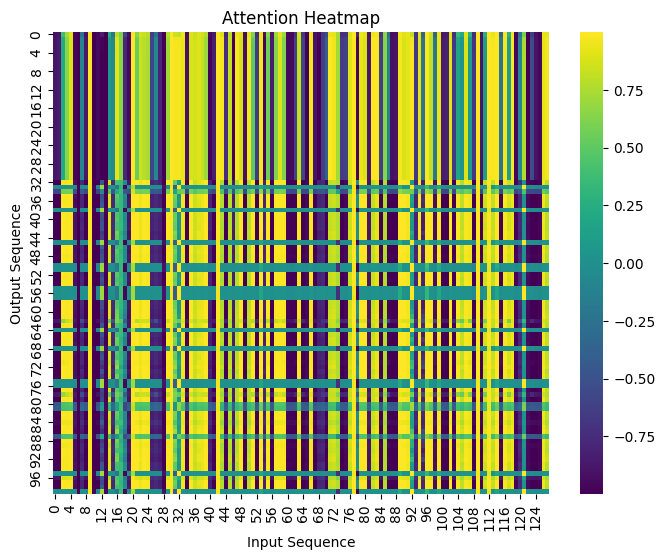

In [6]:
plt.figure(figsize=(8,6))

sns.heatmap(
    attention_weights[0],
    cmap="viridis"
)

plt.xlabel("Input Sequence")
plt.ylabel("Output Sequence")
plt.title("Attention Heatmap")

plt.show()